# Prosperity 4 — Deep EDA Notebook

**Every chart, every number, every insight lens.** Designed for understanding, not brevity.

This notebook is organized as a stack of the six analysis lenses, each with:
- The plot(s) that answer that lens's question
- A summary stats table below each plot
- Markdown cells explaining what to read

**How to use:** run cells top-to-bottom. After each output, stop and write (in your notes) the one-sentence insight this particular cell gave you. If you can't produce an insight, the cell didn't earn its place in the notebook — tell me and I'll rework it.

Data path assumed: `../data/round{N}/`. Change the `ROUND`, `DAYS`, and `DATA_DIR` variables in Cell 1 to point at any round.

In [5]:
# =============== CONFIG ===============
ROUND = 3
DAYS = [0, 1, 2]   # Round 2 has days -1, 0, 1
DATA_DIR = f"../data/round{ROUND}"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 10, 'axes.titlesize': 11,
})

# =============== LOAD & CLEAN ===============
pdfs, tdfs = [], []
for day in DAYS:
    p = pd.read_csv(f"{DATA_DIR}/prices_round_{ROUND}_day_{day}.csv", sep=";")
    pdfs.append(p)
    t = pd.read_csv(f"{DATA_DIR}/trades_round_{ROUND}_day_{day}.csv", sep=";")
    t["day"] = day
    tdfs.append(t)
prices_raw = pd.concat(pdfs, ignore_index=True)
trades = pd.concat(tdfs, ignore_index=True)

garbage = (prices_raw['mid_price'] <= 0) | prices_raw['mid_price'].isna()
prices = prices_raw[~garbage].copy().reset_index(drop=True)

products = sorted(prices['product'].unique())
print(f"Round {ROUND}  |  days: {DAYS}")
print(f"Raw prices: {len(prices_raw)}  |  garbage removed: {garbage.sum()}  |  clean: {len(prices)}")
print(f"Trades: {len(trades)}")
print(f"Products: {products}")

# Color palette per product for consistency
PALETTE = {p: c for p, c in zip(products, ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b'])}

Round 3  |  days: [0, 1, 2]
Raw prices: 360000  |  garbage removed: 0  |  clean: 360000
Trades: 4048
Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


---
# LENS 1 — Shape of the price series

**Question:** is each product stationary, trending, oscillating, or jumpy?  
**Why:** the shape decides the archetype of strategy (market-make vs trend-aware vs jump-protected).

KeyError: 'VEV_5200'

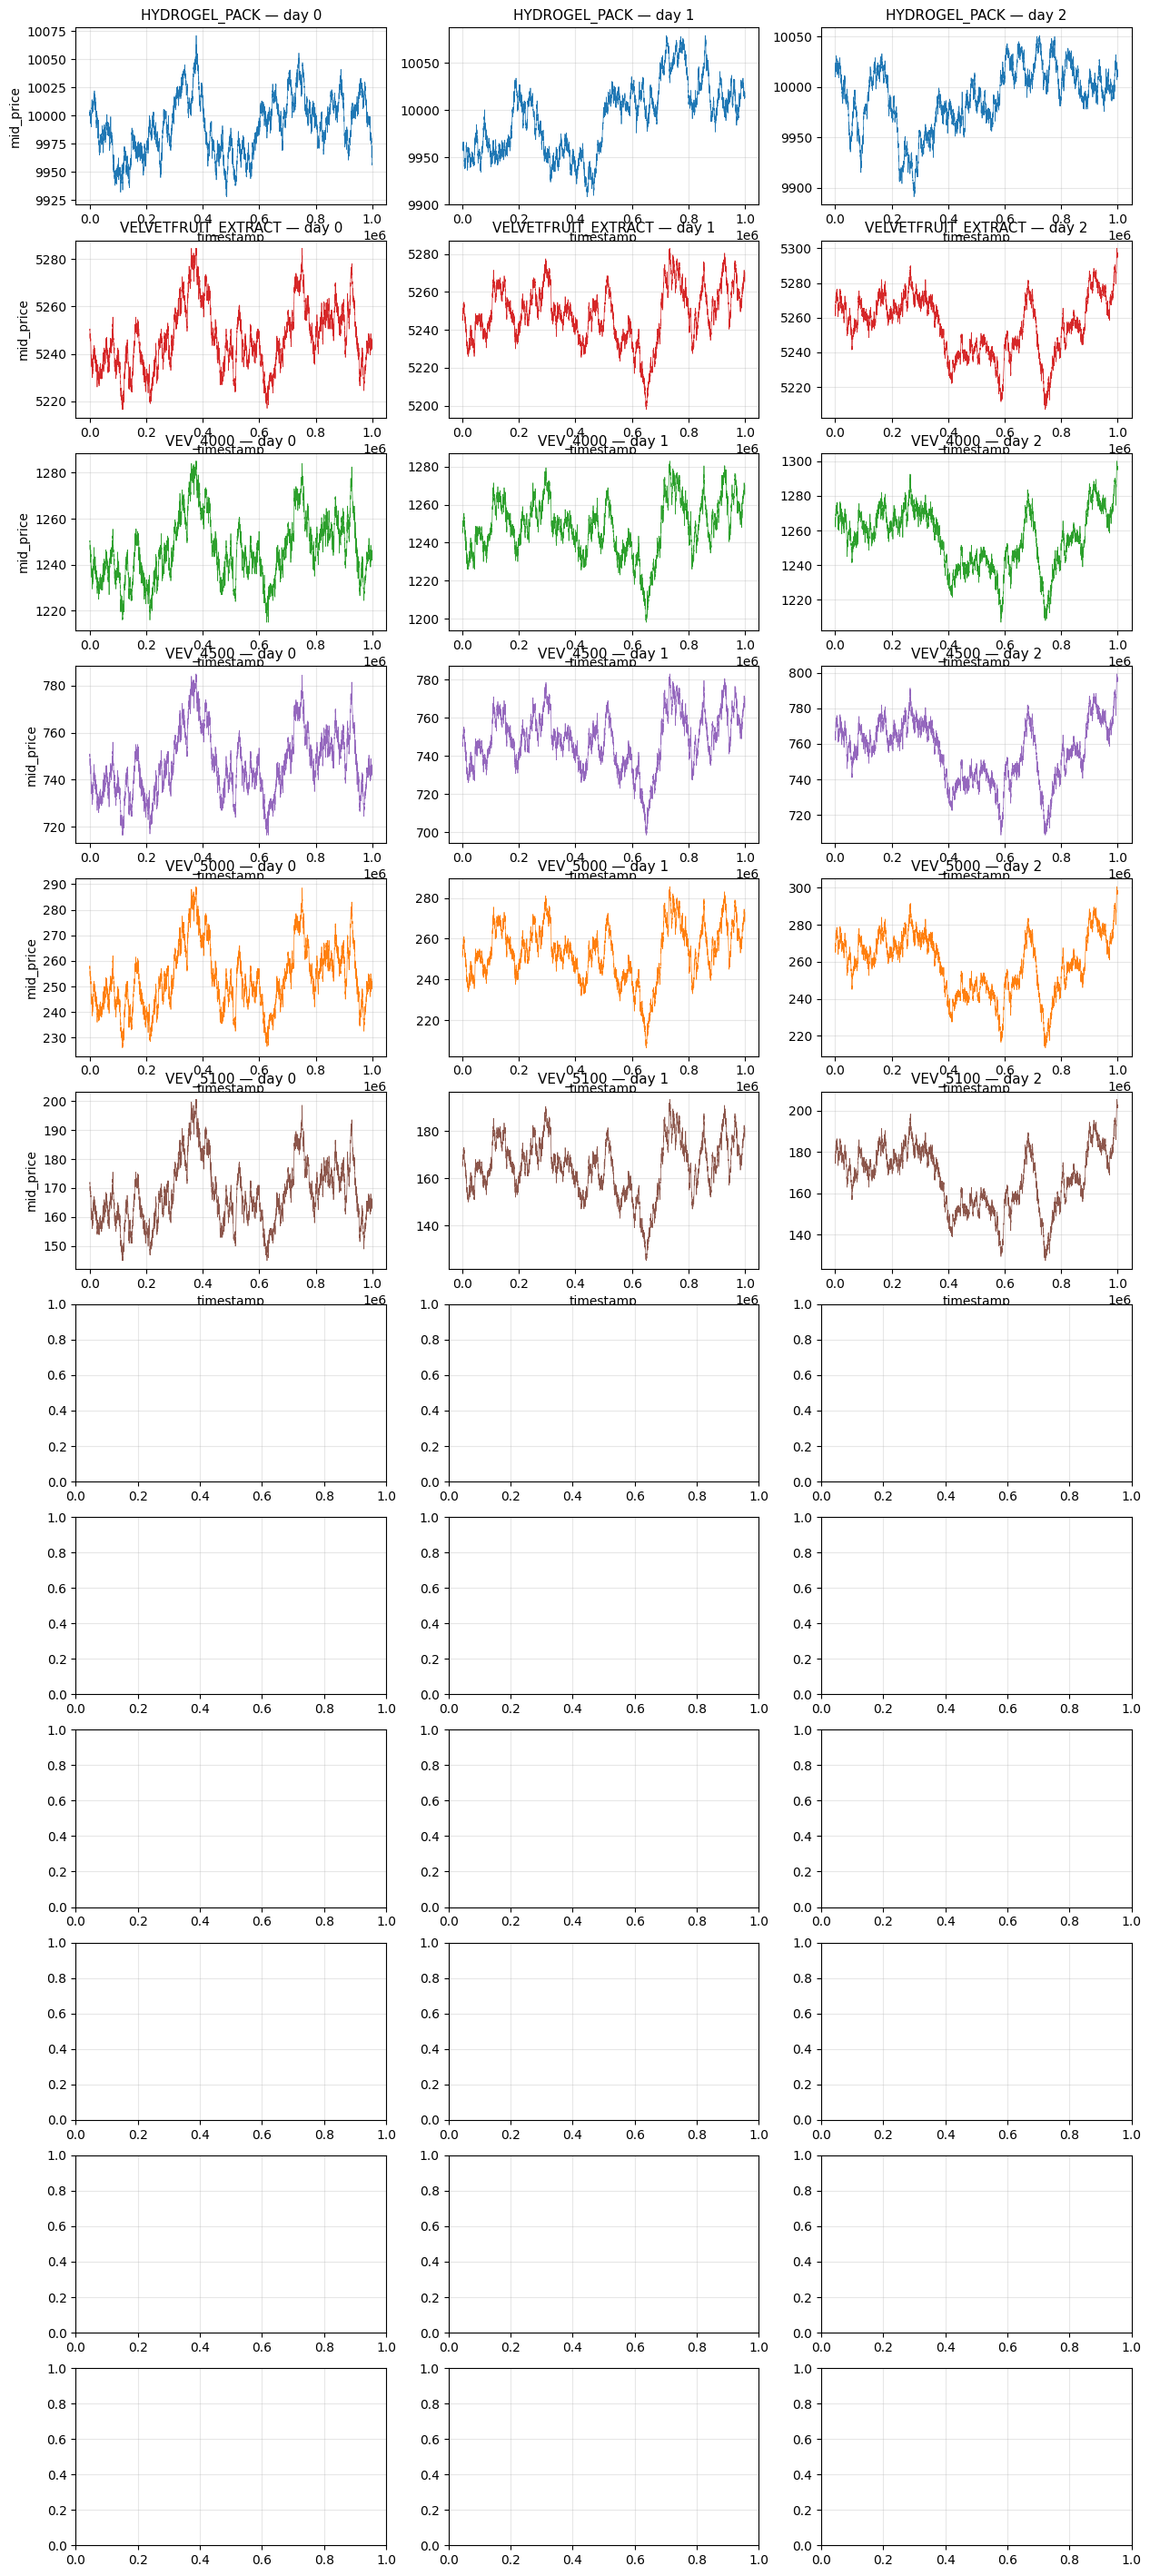

In [6]:
# One row per product, one column per day
ncols = len(DAYS)
fig, axes = plt.subplots(len(products), ncols, figsize=(5*ncols, 3*len(products)), squeeze=False)
for i, product in enumerate(products):
    for j, day in enumerate(DAYS):
        ax = axes[i, j]
        sub = prices[(prices['product']==product) & (prices['day']==day)]
        ax.plot(sub['timestamp'], sub['mid_price'], linewidth=0.5, color=PALETTE[product])
        ax.set_title(f"{product} — day {day}")
        if j==0: ax.set_ylabel('mid_price')
        ax.set_xlabel('timestamp')
plt.tight_layout(); plt.show()

**Read this plot like this:** for each product, do all days look the same shape, or are they different? A consistent shape across days means the product is engineered — you can build a strategy against the shape. Inconsistent shapes means regime change risk.

---
# LENS 2 — Price distribution (histograms)

**Question:** where does each product "live"? One center, two centers, or skewed?  
**Why:** if the distribution is unimodal and bell-shaped, mean/std are valid summary stats. If not, they lie and you need different tools.

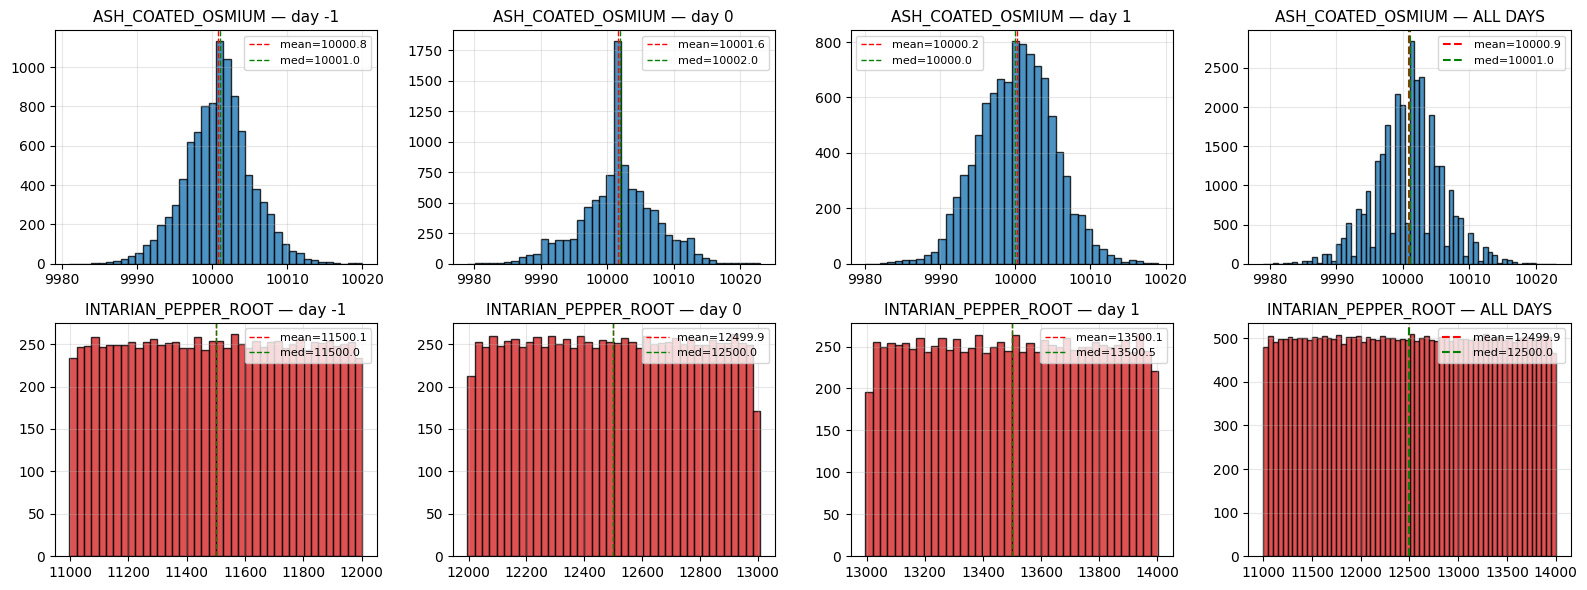

In [ ]:
# Histogram per product per day AND combined
fig, axes = plt.subplots(len(products), ncols+1, figsize=(4*(ncols+1), 3*len(products)), squeeze=False)
for i, product in enumerate(products):
    for j, day in enumerate(DAYS):
        ax = axes[i, j]
        sub = prices[(prices['product']==product) & (prices['day']==day)]['mid_price']
        ax.hist(sub, bins=40, color=PALETTE[product], edgecolor='black', alpha=0.8)
        ax.axvline(sub.mean(), color='red', linestyle='--', linewidth=1, label=f'mean={sub.mean():.1f}')
        ax.axvline(sub.median(), color='green', linestyle='--', linewidth=1, label=f'med={sub.median():.1f}')
        ax.set_title(f"{product} — day {day}")
        ax.legend(fontsize=8)
    # combined
    ax = axes[i, ncols]
    sub = prices[prices['product']==product]['mid_price']
    ax.hist(sub, bins=60, color=PALETTE[product], edgecolor='black', alpha=0.8)
    ax.axvline(sub.mean(), color='red', linestyle='--', label=f'mean={sub.mean():.1f}')
    ax.axvline(sub.median(), color='green', linestyle='--', label=f'med={sub.median():.1f}')
    ax.set_title(f"{product} — ALL DAYS")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Summary table: per-day centers, std, skew, kurtosis
rows = []
for product in products:
    for day in DAYS:
        s = prices[(prices['product']==product) & (prices['day']==day)]['mid_price']
        rows.append({
            'product': product, 'day': day,
            'count': len(s),
            'mean': round(s.mean(), 2),
            'median': round(s.median(), 2),
            'std': round(s.std(), 2),
            'min': s.min(), 'max': s.max(),
            'range': s.max()-s.min(),
            'skew': round(s.skew(), 3),
            'kurt': round(s.kurtosis(), 3),
        })
summary_price = pd.DataFrame(rows)
print("PRICE DISTRIBUTION SUMMARY (per product per day):")
print(summary_price.to_string(index=False))

PRICE DISTRIBUTION SUMMARY (per product per day):
             product  day  count     mean  median    std     min     max  range   skew   kurt
   ASH_COATED_OSMIUM   -1   9985 10000.83 10001.0   4.47  9981.0 10020.0   39.0 -0.032  0.743
   ASH_COATED_OSMIUM    0   9984 10001.61 10002.0   5.66  9979.0 10023.0   44.0 -0.175  0.543
   ASH_COATED_OSMIUM    1   9978 10000.21 10000.0   5.02  9980.0 10019.0   39.0  0.004  0.203
INTARIAN_PEPPER_ROOT   -1   9987 11500.12 11500.0 288.65 10998.0 12001.5 1003.5 -0.001 -1.199
INTARIAN_PEPPER_ROOT    0   9982 12499.87 12500.0 288.61 11996.0 13008.0 1012.0 -0.000 -1.200
INTARIAN_PEPPER_ROOT    1   9984 13500.06 13500.5 288.75 12995.0 14003.0 1008.0 -0.001 -1.201


**How to interpret the summary table:**
- `mean ≈ median` → symmetric. If they diverge → skewed.
- `std` tells you how wide the distribution is.
- `skew` near 0 = symmetric; positive = long right tail; negative = long left tail.
- `kurt` near 0 = bell-curve-like; high positive = fat tails (jumps).
- `range = max - min` large relative to `std` also hints at fat tails.

---
# LENS 3 — Returns distribution and volatility

**Question:** how noisy is each product, and is the noise well-behaved?  
**Why:** volatility is the main cost for market makers. Shape tells you about jump risk.

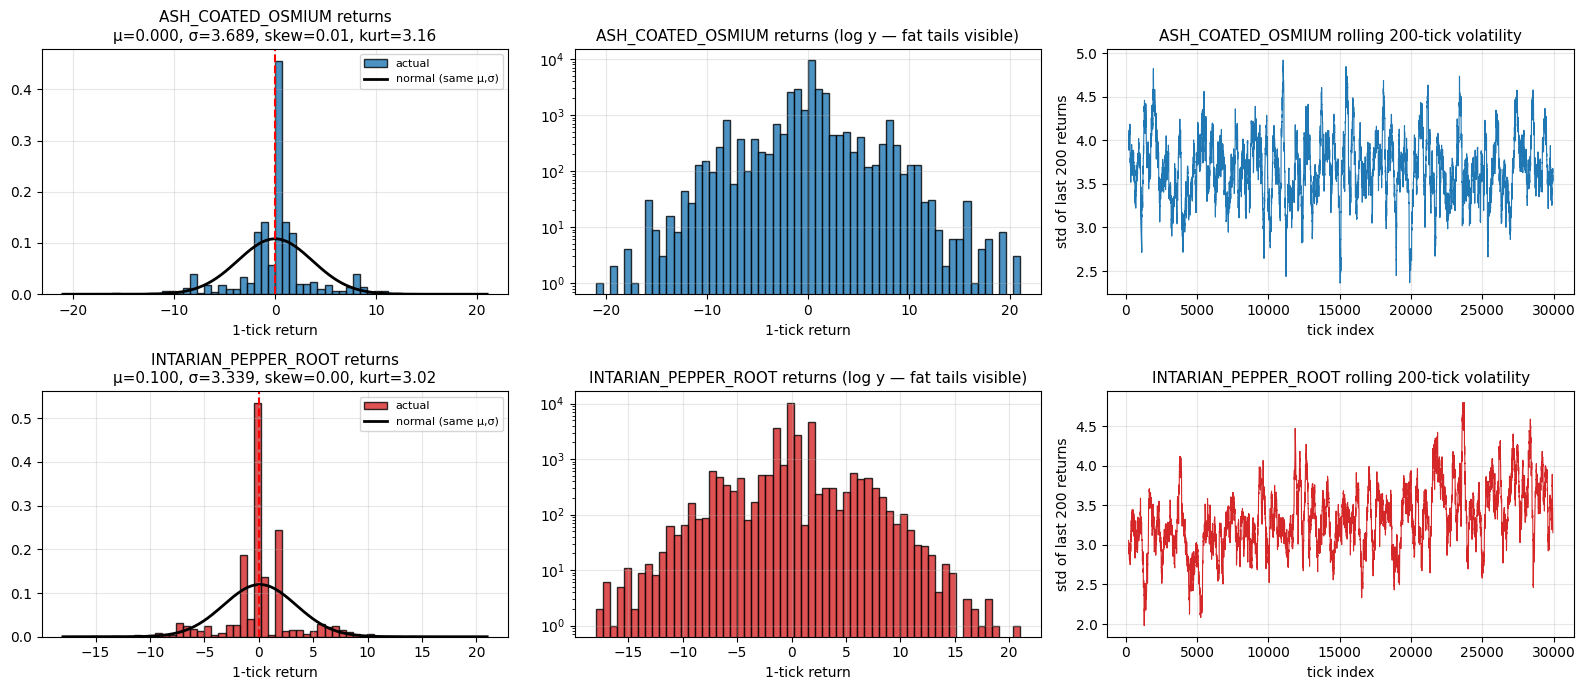

In [ ]:
# Compute per-day returns, then plot histograms AND price-vs-returns side by side
fig, axes = plt.subplots(len(products), 3, figsize=(16, 3.5*len(products)), squeeze=False)
returns_dict = {}
for i, product in enumerate(products):
    sub = prices[prices['product']==product].sort_values(['day','timestamp']).reset_index(drop=True)
    rets = sub.groupby('day')['mid_price'].diff().dropna()
    returns_dict[product] = rets
    
    # (1) returns histogram with normal overlay
    ax = axes[i, 0]
    ax.hist(rets, bins=60, color=PALETTE[product], edgecolor='black', alpha=0.8, density=True, label='actual')
    mu, sig = rets.mean(), rets.std()
    xr = np.linspace(rets.min(), rets.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr, mu, sig), color='black', linewidth=2, label='normal (same μ,σ)')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f"{product} returns\nμ={mu:.3f}, σ={sig:.3f}, skew={rets.skew():.2f}, kurt={rets.kurtosis():.2f}")
    ax.set_xlabel('1-tick return')
    ax.legend(fontsize=8)
    
    # (2) returns histogram in LOG scale (to reveal fat tails)
    ax = axes[i, 1]
    ax.hist(rets, bins=60, color=PALETTE[product], edgecolor='black', alpha=0.8)
    ax.set_yscale('log')
    ax.set_title(f"{product} returns (log y — fat tails visible)")
    ax.set_xlabel('1-tick return')
    
    # (3) rolling volatility over time
    ax = axes[i, 2]
    roll = rets.rolling(200).std()
    ax.plot(roll.values, linewidth=0.8, color=PALETTE[product])
    ax.set_title(f"{product} rolling 200-tick volatility")
    ax.set_xlabel('tick index'); ax.set_ylabel('std of last 200 returns')
plt.tight_layout(); plt.show()

In [ ]:
# Returns summary table
rows = []
for product, rets in returns_dict.items():
    q = rets.quantile([0.01, 0.05, 0.95, 0.99])
    rows.append({
        'product': product,
        'mean_return': round(rets.mean(), 4),
        'std (vol)': round(rets.std(), 3),
        'skew': round(rets.skew(), 3),
        'excess_kurt': round(rets.kurtosis(), 3),
        '1%tile': round(q[0.01], 2), '99%tile': round(q[0.99], 2),
        'max abs return': round(rets.abs().max(), 2),
        'pct |ret|>3σ': round(((rets.abs() > 3*rets.std()).mean())*100, 2),
    })
print("RETURNS SUMMARY (volatility & distribution shape):")
print(pd.DataFrame(rows).to_string(index=False))

RETURNS SUMMARY (volatility & distribution shape):
             product  mean_return  std (vol)  skew  excess_kurt  1%tile  99%tile  max abs return  pct |ret|>3σ
   ASH_COATED_OSMIUM       0.0000      3.689 0.011        3.160  -10.28     10.0            21.0          0.93
INTARIAN_PEPPER_ROOT       0.1001      3.339 0.003        3.022   -9.50      9.5            21.0          1.31


**How to read the returns table:**
- `std (vol)` = the key volatility number. Your quotes must be wider than ~1-2× this from fair.
- `skew` near 0 = symmetric up/down moves. Nonzero = asymmetric risk.
- `excess_kurt`: 0 = normal. >3 means fat tails — rare big moves matter. >10 means very jumpy.
- `pct |ret|>3σ`: under a normal distribution this should be 0.27%. Much higher = fat tails.

---
# LENS 4 — Autocorrelation across multiple lags

**Question:** does the past predict the future? Is there real mean reversion or momentum?  
**Why:** this is the main filter against "lag-1 rounding artifact" traps.

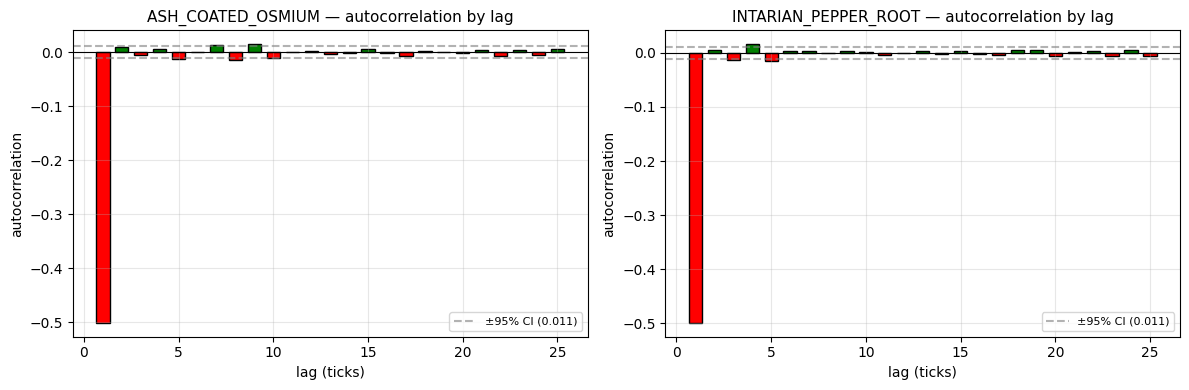


FIRST 10 LAGS NUMERICALLY:
             product   lag1  lag2   lag3  lag4   lag5  lag6  lag7   lag8  lag9  lag10
   ASH_COATED_OSMIUM -0.501 0.009 -0.006 0.007 -0.012 0.001 0.013 -0.014 0.015 -0.010
INTARIAN_PEPPER_ROOT -0.499 0.005 -0.013 0.016 -0.015 0.004 0.002 -0.001 0.003  0.001


In [ ]:
# Autocorrelation bar chart per product for lags 1..25
lags = list(range(1, 26))
fig, axes = plt.subplots(1, len(products), figsize=(6*len(products), 4), squeeze=False)
rows = []
for i, product in enumerate(products):
    rets = returns_dict[product]
    acs = [rets.autocorr(l) for l in lags]
    ax = axes[0, i]
    colors = ['red' if a < 0 else 'green' for a in acs]
    ax.bar(lags, acs, color=colors, edgecolor='black', width=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    # 95% confidence band for "no autocorrelation"
    ci = 1.96 / np.sqrt(len(rets))
    ax.axhline(ci, color='gray', linestyle='--', alpha=0.6, label=f'±95% CI ({ci:.3f})')
    ax.axhline(-ci, color='gray', linestyle='--', alpha=0.6)
    ax.set_title(f"{product} — autocorrelation by lag")
    ax.set_xlabel('lag (ticks)'); ax.set_ylabel('autocorrelation')
    ax.legend(fontsize=8)
    rows.append({'product': product, **{f'lag{l}': round(a,3) for l,a in zip(lags[:10], acs[:10])}})
plt.tight_layout(); plt.show()
print("\nFIRST 10 LAGS NUMERICALLY:")
print(pd.DataFrame(rows).to_string(index=False))

**How to read the autocorrelation bars:**
- Bars inside the ±95% CI (gray dashed lines) are statistically indistinguishable from zero.
- A spike at lag 1 with everything else in the band = **rounding artifact**, NOT tradeable reversion.
- A decaying pattern of negative bars across several lags = **real mean reversion**.
- A decaying pattern of positive bars = **real momentum**.

---
# LENS 5 — Spread vs volatility (the MM-viability test)

**Question:** is the spread wide enough to make market-making profitable?  
**Why:** the spread/volatility ratio is the single most important viability metric.

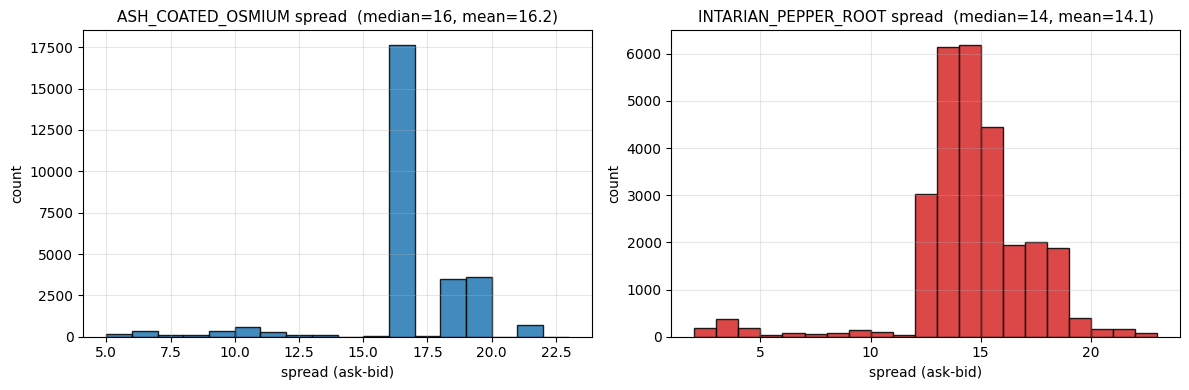


MARKET-MAKING VIABILITY TABLE:
             product  spread_median  spread_mean  spread_mode  returns_vol  ratio (spread/vol) MM verdict
   ASH_COATED_OSMIUM           16.0        16.23           16         3.69                4.34     VIABLE
INTARIAN_PEPPER_ROOT           14.0        14.12           14         3.34                4.19     VIABLE


In [ ]:
# Spread distribution histogram + summary
fig, axes = plt.subplots(1, len(products), figsize=(6*len(products), 4), squeeze=False)
spread_rows = []
for i, product in enumerate(products):
    p = prices_raw[(prices_raw['product']==product) & prices_raw['bid_price_1'].notna() & prices_raw['ask_price_1'].notna()]
    spread = (p['ask_price_1'] - p['bid_price_1']).astype(int)
    ax = axes[0, i]
    uniq = sorted(spread.unique())
    ax.hist(spread, bins=range(min(uniq), max(uniq)+2), color=PALETTE[product], edgecolor='black', alpha=0.85)
    ax.set_title(f"{product} spread  (median={spread.median():.0f}, mean={spread.mean():.1f})")
    ax.set_xlabel('spread (ask-bid)'); ax.set_ylabel('count')
    
    vol = returns_dict[product].std()
    ratio = spread.median() / vol
    spread_rows.append({
        'product': product,
        'spread_median': spread.median(),
        'spread_mean': round(spread.mean(), 2),
        'spread_mode': int(spread.mode().iloc[0]),
        'returns_vol': round(vol, 2),
        'ratio (spread/vol)': round(ratio, 2),
        'MM verdict': 'VIABLE' if ratio >= 3 else ('MARGINAL' if ratio >= 1.5 else 'BAD'),
    })
plt.tight_layout(); plt.show()
print("\nMARKET-MAKING VIABILITY TABLE:")
print(pd.DataFrame(spread_rows).to_string(index=False))

**How to read the viability table:**
- `ratio ≥ 3` → market-making is a clear edge. Quote both sides, collect spread.
- `1.5 ≤ ratio < 3` → marginal. Works only if flow is balanced.
- `ratio < 1.5` → bad. Volatility eats the spread. Don't MM without additional edge.

If the histogram has multiple peaks (bimodal), check each regime separately — see next cell.

In [ ]:
# Bimodal spread detection — are there multiple "regimes"?
for product in products:
    p = prices_raw[(prices_raw['product']==product) & prices_raw['bid_price_1'].notna() & prices_raw['ask_price_1'].notna()]
    spread = (p['ask_price_1'] - p['bid_price_1']).astype(int)
    vc = spread.value_counts().sort_index()
    print(f"\n{product} spread frequency (top 10 values):")
    print(vc.head(10))
    dominant = vc.idxmax()
    share = vc.max() / len(spread)
    print(f"  Dominant spread = {dominant} ({share:.1%} of ticks)")
    if share < 0.5:
        print(f"  ⚠️  No single spread dominates — market likely has multiple regimes (different MMs active at different times)")


ASH_COATED_OSMIUM spread frequency (top 10 values):
5     137
6     327
7     134
8      74
9     321
10    607
11    297
12    126
13    132
15     66
Name: count, dtype: int64
  Dominant spread = 16 (63.7% of ticks)

INTARIAN_PEPPER_ROOT spread frequency (top 10 values):
2     178
3     369
4     192
5      36
6      84
7      48
8      77
9     134
10    105
11     27
Name: count, dtype: int64
  Dominant spread = 14 (22.3% of ticks)
  ⚠️  No single spread dominates — market likely has multiple regimes (different MMs active at different times)


---
# LENS 6 — Trade flow (who's trading and where?)

**Question:** are there exploitable counterparty patterns — a bot, a consistent aggressor, a daily-extremes pattern?  
**Why:** this is the highest-leverage analysis. A decoded bot is near-zero-risk alpha.

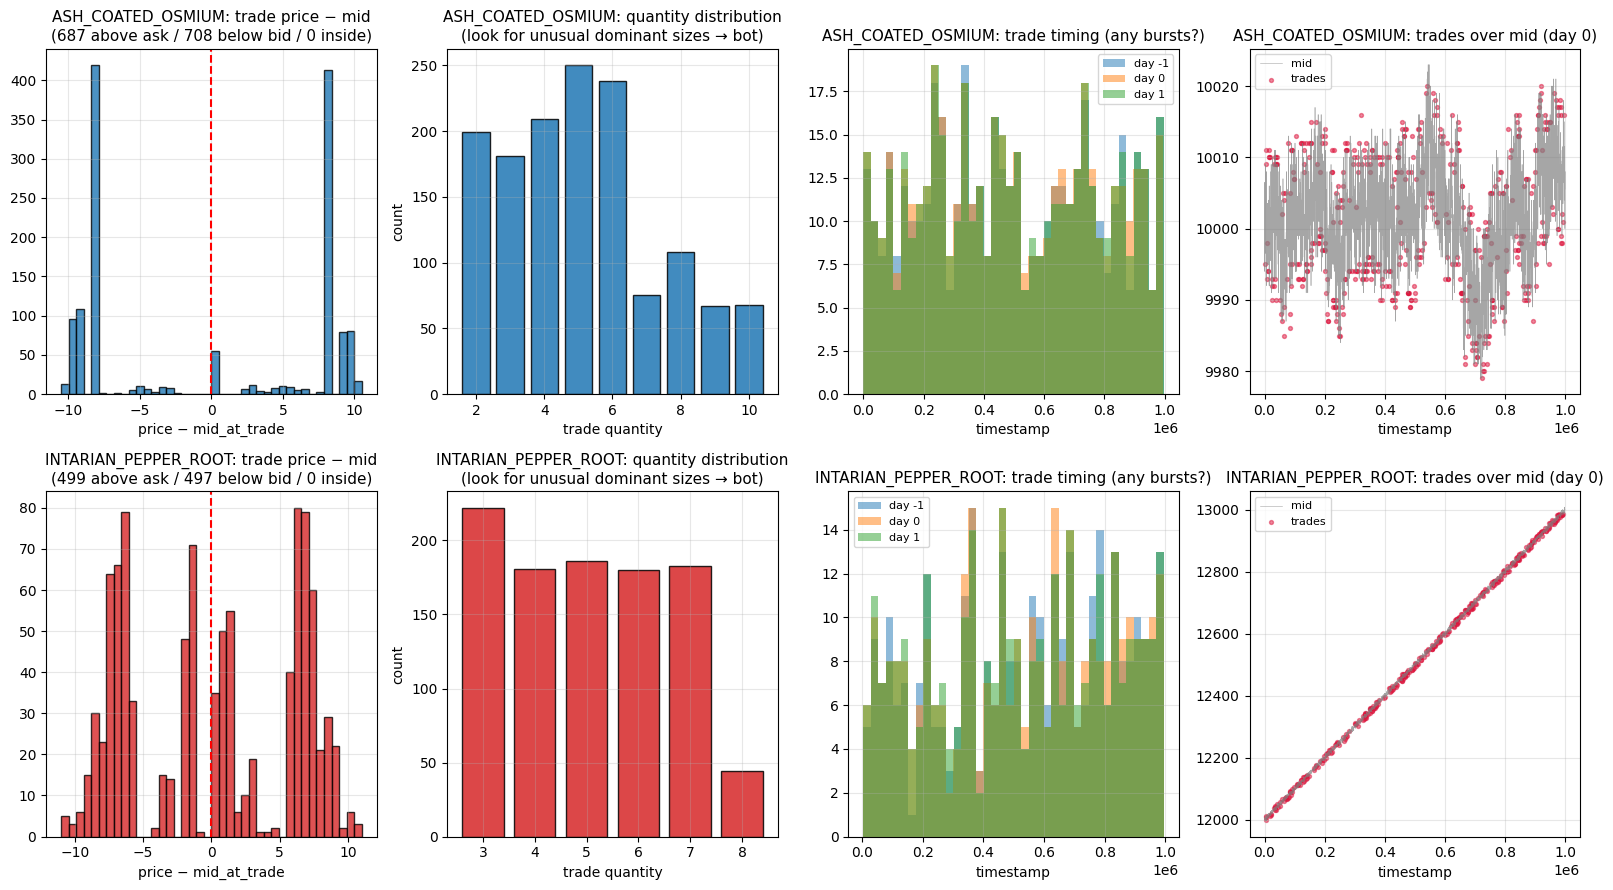


FLOW SUMMARY:
             product  n_trades pct_hit_ask (agg buys) pct_hit_bid (agg sells) pct_inside  mean_qty  dominant_qty dominant_qty_share
   ASH_COATED_OSMIUM      1395                  49.2%                   50.8%       0.0%      5.11             5              17.9%
INTARIAN_PEPPER_ROOT       996                  50.1%                   49.9%       0.0%      5.05             3              22.3%


In [ ]:
# Enrich trades with mid/bid/ask at trade time
keys = ['day','timestamp','product']
trade_enriched = trades.rename(columns={'symbol':'product'}).merge(
    prices[['day','timestamp','product','mid_price','bid_price_1','ask_price_1']],
    on=keys, how='left'
)

# Per-product flow analytics
fig = plt.figure(figsize=(16, 4.5*len(products)))
gs = gridspec.GridSpec(len(products), 4, figure=fig)

flow_rows = []
for i, product in enumerate(products):
    t = trade_enriched[trade_enriched['product']==product].copy()
    t['diff_from_mid'] = t['price'] - t['mid_price']
    hit_ask = (t['price'] >= t['ask_price_1']).sum()
    hit_bid = (t['price'] <= t['bid_price_1']).sum()
    inside = len(t) - hit_ask - hit_bid
    
    # (a) trade price − mid histogram
    ax = fig.add_subplot(gs[i, 0])
    ax.hist(t['diff_from_mid'].dropna(), bins=40, color=PALETTE[product], edgecolor='black', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f"{product}: trade price − mid\n({hit_ask} above ask / {hit_bid} below bid / {inside} inside)")
    ax.set_xlabel('price − mid_at_trade')
    
    # (b) quantity distribution
    ax = fig.add_subplot(gs[i, 1])
    vc = t['quantity'].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=PALETTE[product], edgecolor='black', alpha=0.85)
    ax.set_title(f"{product}: quantity distribution\n(look for unusual dominant sizes → bot)")
    ax.set_xlabel('trade quantity'); ax.set_ylabel('count')
    
    # (c) trade times density
    ax = fig.add_subplot(gs[i, 2])
    for day in DAYS:
        day_t = t[t['day']==day]
        ax.hist(day_t['timestamp'], bins=40, alpha=0.5, label=f'day {day}')
    ax.set_title(f"{product}: trade timing (any bursts?)")
    ax.set_xlabel('timestamp'); ax.legend(fontsize=8)
    
    # (d) scatter: trade price on mid curve (day 0 only)
    ax = fig.add_subplot(gs[i, 3])
    d0p = prices[(prices['product']==product) & (prices['day']==DAYS[len(DAYS)//2])].sort_values('timestamp')
    d0t = t[t['day']==DAYS[len(DAYS)//2]]
    ax.plot(d0p['timestamp'], d0p['mid_price'], color='gray', linewidth=0.4, alpha=0.7, label='mid')
    ax.scatter(d0t['timestamp'], d0t['price'], s=8, c='crimson', alpha=0.5, label='trades')
    ax.set_title(f"{product}: trades over mid (day {DAYS[len(DAYS)//2]})")
    ax.set_xlabel('timestamp'); ax.legend(fontsize=8)
    
    flow_rows.append({
        'product': product,
        'n_trades': len(t),
        'pct_hit_ask (agg buys)': f"{hit_ask/len(t)*100:.1f}%",
        'pct_hit_bid (agg sells)': f"{hit_bid/len(t)*100:.1f}%",
        'pct_inside': f"{inside/len(t)*100:.1f}%",
        'mean_qty': round(t['quantity'].mean(), 2),
        'dominant_qty': int(t['quantity'].mode().iloc[0]),
        'dominant_qty_share': f"{(t['quantity']==t['quantity'].mode().iloc[0]).mean()*100:.1f}%",
    })
plt.tight_layout(); plt.show()
print("\nFLOW SUMMARY:")
print(pd.DataFrame(flow_rows).to_string(index=False))

In [ ]:
# Daily extremes bot-hunt: trades at local highs/lows with fixed size?
print("\nDAILY-EXTREMES TRADE PATTERN (Olivia-style bot hunt):\n")
for product in products:
    for day in DAYS:
        day_pr = prices[(prices['product']==product) & (prices['day']==day)]
        if len(day_pr) == 0: continue
        lo, hi = day_pr['mid_price'].min(), day_pr['mid_price'].max()
        t = trades[(trades['symbol']==product) & (trades['day']==day)]
        near_lo = t[t['price'] <= lo + 2]
        near_hi = t[t['price'] >= hi - 2]
        lo_qty = dict(near_lo['quantity'].value_counts().head(3))
        hi_qty = dict(near_hi['quantity'].value_counts().head(3))
        print(f"  {product} day {day}: range [{lo:.0f}, {hi:.0f}] (span {hi-lo:.0f})")
        print(f"     near LOW:  {len(near_lo)} trades, sizes={lo_qty}")
        print(f"     near HIGH: {len(near_hi)} trades, sizes={hi_qty}")


DAILY-EXTREMES TRADE PATTERN (Olivia-style bot hunt):

  ASH_COATED_OSMIUM day -1: range [9981, 10020] (span 39)
     near LOW:  2 trades, sizes={6: 2}
     near HIGH: 2 trades, sizes={2: 2}
  ASH_COATED_OSMIUM day 0: range [9979, 10023] (span 44)
     near LOW:  7 trades, sizes={5: 3, 3: 1, 6: 1}
     near HIGH: 0 trades, sizes={}
  ASH_COATED_OSMIUM day 1: range [9980, 10019] (span 39)
     near LOW:  2 trades, sizes={2: 1, 4: 1}
     near HIGH: 7 trades, sizes={3: 3, 2: 2, 7: 1}
  INTARIAN_PEPPER_ROOT day -1: range [10998, 12002] (span 1004)
     near LOW:  1 trades, sizes={5: 1}
     near HIGH: 0 trades, sizes={}
  INTARIAN_PEPPER_ROOT day 0: range [11996, 13008] (span 1012)
     near LOW:  1 trades, sizes={5: 1}
     near HIGH: 0 trades, sizes={}
  INTARIAN_PEPPER_ROOT day 1: range [12995, 14003] (span 1008)
     near LOW:  0 trades, sizes={}
     near HIGH: 0 trades, sizes={}


**How to read Lens 6 output:**

**Trade price − mid histogram (column 1):** if it's bimodal with peaks near ±spread/2, that's normal — trades happen at the touch. If it's skewed or asymmetric, that's pressure in one direction.

**Quantity distribution (column 2):** a clean descending staircase = random noise traders. A suspicious spike at one value = bot fingerprint. Compare that spike's quantity with the daily-extremes table — if the same size shows up at extremes, you've found an Olivia.

**Trade timing (column 3):** flat distribution = steady flow. Bursts = event-driven.

**Scatter over mid (column 4):** trades evenly scattered around mid = no pattern. Clustering at extremes = pattern.

---
# FINAL — The thesis per product

Fill this in after reading all lenses above. Template:

For each product, state:
1. **Archetype** (stationary / trending / sawtooth / jumpy)
2. **Fair value estimator** (fixed number / wall_mid / trend line / regime-dependent)
3. **Volatility (σ)** and **median spread** and **ratio**
4. **Bot signals detected** (yes/no, description)
5. **Strategy** (market-make / trend-aware MM / arb / mean-revert / momentum / bot-follow)
6. **Expected edge per round-trip** (in seashells)

In [ ]:
# Thesis dashboard — one card per product
print("="*80)
print("THESIS DASHBOARD")
print("="*80)
for product in products:
    sub = prices[prices['product']==product]
    rets = returns_dict[product]
    p = prices_raw[(prices_raw['product']==product) & prices_raw['bid_price_1'].notna() & prices_raw['ask_price_1'].notna()]
    spread = (p['ask_price_1'] - p['bid_price_1'])
    t = trade_enriched[trade_enriched['product']==product]
    
    print(f"\n### {product} ###")
    print(f"  Mid:        mean={sub['mid_price'].mean():.2f}, std={sub['mid_price'].std():.2f}, range=[{sub['mid_price'].min():.0f}, {sub['mid_price'].max():.0f}]")
    print(f"  Returns:    σ={rets.std():.3f}, skew={rets.skew():.2f}, excess kurt={rets.kurtosis():.2f}")
    print(f"  Spread:     median={spread.median():.0f}, mean={spread.mean():.1f}, mode={int(spread.mode().iloc[0])}")
    print(f"  Ratio:      spread_median / σ = {spread.median()/rets.std():.2f}")
    print(f"  Flow:       {len(t)} trades, {(t['price']>=t['ask_price_1']).mean()*100:.1f}% hit ask, {(t['price']<=t['bid_price_1']).mean()*100:.1f}% hit bid")
    print(f"  Dominant qty: {int(t['quantity'].mode().iloc[0])} ({(t['quantity']==t['quantity'].mode().iloc[0]).mean()*100:.1f}% of trades)")
    print(f"  Lag autocorrs: " + ", ".join(f"l{l}={rets.autocorr(l):+.2f}" for l in [1,2,5,10]))

THESIS DASHBOARD

### ASH_COATED_OSMIUM ###
  Mid:        mean=10000.88, std=5.10, range=[9979, 10023]
  Returns:    σ=3.689, skew=0.01, excess kurt=3.16
  Spread:     median=16, mean=16.2, mode=16
  Ratio:      spread_median / σ = 4.34
  Flow:       1395 trades, 49.2% hit ask, 50.8% hit bid
  Dominant qty: 5 (17.9% of trades)
  Lag autocorrs: l1=-0.50, l2=+0.01, l5=-0.01, l10=-0.01

### INTARIAN_PEPPER_ROOT ###
  Mid:        mean=12499.92, std=866.05, range=[10998, 14003]
  Returns:    σ=3.339, skew=0.00, excess kurt=3.02
  Spread:     median=14, mean=14.1, mode=14
  Ratio:      spread_median / σ = 4.19
  Flow:       996 trades, 50.1% hit ask, 49.9% hit bid
  Dominant qty: 3 (22.3% of trades)
  Lag autocorrs: l1=-0.50, l2=+0.01, l5=-0.01, l10=+0.00
